In [1]:
import sys
from pathlib import Path

parent = Path().resolve().parent.parent 
sys.path.append(str(parent))

In [ ]:
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import *
import numpy as np

In [ ]:
from data.test_data.HanSeg_to_npz import CTProcessor, MRIProcessor

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def visualize_img_with_mask(mri, mask, alpha=0.5):
    assert mri.shape == mask.shape

    depth = mri.shape[0]

    def show_slice(idx):
        plt.figure(figsize=(6,6))
        plt.imshow(mri[idx], cmap='gray')
        plt.imshow(mask[idx], cmap='jet', alpha=alpha)
        plt.title(f"Slice {idx}")
        plt.axis('off')
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=depth-1,
        step=1,
        description='Slice:'
    )

    widgets.interact(show_slice, idx=slider)

# CT

In [5]:
# CT pipeline
proc = CTProcessor("HanSeg/set_1", oar_csv_path="HanSeg/set_1/OAR_data.csv")
proc.process_dataset("HanSeg_CT")

Loading OAR availability from HanSeg/set_1/OAR_data.csv

[1/4] Processing case_04 ...
  Resampling from spacing ('2.00', '0.60', '0.60') mm → 1.0 mm isotropic ...
  -> Resampled shape: (278, 400, 565)
  -> Success: shape (278, 400, 565), modality=CT

[2/4] Processing case_18 ...
  Resampling from spacing ('3.00', '0.61', '0.61') mm → 1.0 mm isotropic ...
  -> Resampled shape: (363, 440, 567)
  -> Success: shape (363, 440, 567), modality=CT

[3/4] Processing case_25 ...
  Resampling from spacing ('2.00', '0.68', '0.68') mm → 1.0 mm isotropic ...
  -> Resampled shape: (294, 425, 573)
  -> Success: shape (294, 425, 573), modality=CT

[4/4] Processing case_40 ...
  Resampling from spacing ('2.00', '0.59', '0.59') mm → 1.0 mm isotropic ...
  -> Resampled shape: (310, 403, 563)
  -> Success: shape (310, 403, 563), modality=CT

Saving dataset to HanSeg_CT.npz ...
Save complete!

OAR Mapping: {'A_Carotid_L': 1, 'A_Carotid_R': 2, 'Arytenoid': 3, 'Bone_Mandible': 4, 'Brainstem': 5, 'BuccalMucosa

In [11]:
dg_ct = DataGenerator(DataLoader_npz(["data/test_data/HanSeg_CT.npz"], val_size=0.0))


Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\HanSeg_CT.npz

Final dataset size: 4 patients.



In [12]:
print(dg_ct.dataloader.train_ids)
print(dg_ct.dataloader.validation_ids)

['HanSeg_CT_case_40', 'HanSeg_CT_case_18', 'HanSeg_CT_case_04', 'HanSeg_CT_case_25']
[]


In [13]:
img_ct = dg_ct.dataloader.dataset['HanSeg_CT_case_04']['image']
segmentations_ct = dg_ct.dataloader.dataset['HanSeg_CT_case_04']['segmentations']

In [14]:
print(segmentations_ct[0].shape)
print(img_ct.shape)

(278, 400, 565)
(278, 400, 565)


In [15]:
visualize_img_with_mask(img_ct, segmentations_ct[0])

interactive(children=(IntSlider(value=0, description='Slice:', max=277), Output()), _dom_classes=('widget-inte…

In [16]:
# ds, offset_list = dg_ct.get_data_points(max_data_points=100, offset=10, max_number_labels=3, cropping=True, min_crop_size=0.4)
ds, offset_list = dg_ct.get_data_points(max_data_points=100, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 40 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


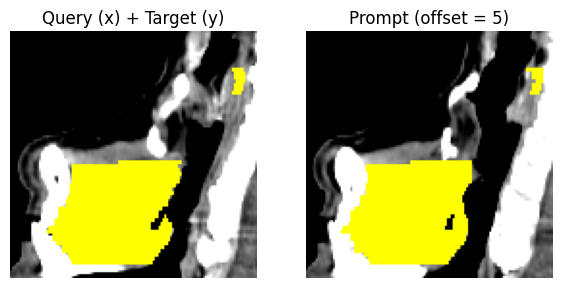

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


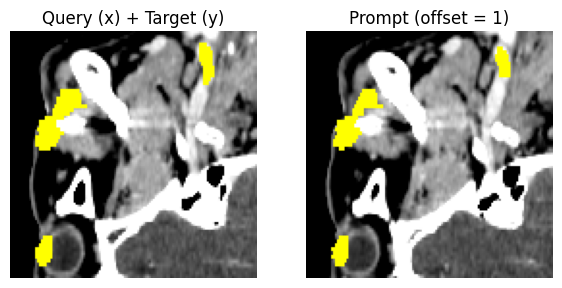

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


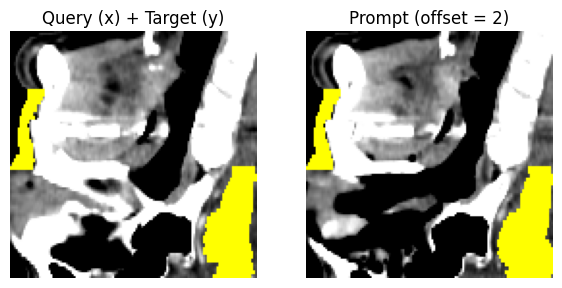

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


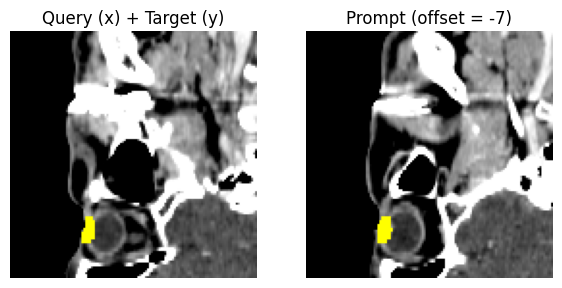

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


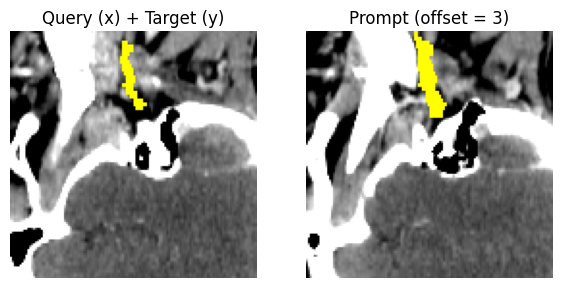

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


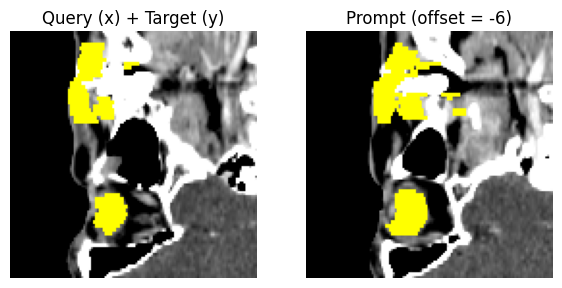


x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


In [17]:
for counter,(x,y,p) in enumerate(ds):
    plot_one_dp(x,y,p, offset_list[counter])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if counter == 5:
        break

# MRI

In [12]:
# MRI pipeline
proc = MRIProcessor("HanSeg/set_1", oar_csv_path="HanSeg/set_1/OAR_data.csv")
proc.process_dataset("HanSeg_MRI")

Loading OAR availability from HanSeg/set_1/OAR_data.csv

[1/4] Processing case_04 ...
  Registration OK  (metric = -0.5189)
  Resampling from spacing ('2.00', '0.60', '0.60') mm → 1.0 mm isotropic ...
  -> Resampled shape: (174, 259, 254)
  -> Success: shape (174, 259, 254), modality=MRI

[2/4] Processing case_18 ...
  Registration OK  (metric = -0.5916)
  Resampling from spacing ('3.00', '0.61', '0.61') mm → 1.0 mm isotropic ...
  -> Resampled shape: (213, 271, 267)
  -> Success: shape (213, 271, 267), modality=MRI

[3/4] Processing case_25 ...
  Registration OK  (metric = -0.7012)
  Resampling from spacing ('2.00', '0.68', '0.68') mm → 1.0 mm isotropic ...
  -> Resampled shape: (232, 261, 258)
  -> Success: shape (232, 261, 258), modality=MRI

[4/4] Processing case_40 ...
  Registration OK  (metric = -0.6725)
  Resampling from spacing ('2.00', '0.59', '0.59') mm → 1.0 mm isotropic ...
  -> Resampled shape: (210, 261, 257)
  -> Success: shape (210, 261, 257), modality=MRI

Saving data

In [5]:
dg_mr = DataGenerator(DataLoader_npz(["data/test_data/HanSeg_MRI.npz"], val_size=0.0))


Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\HanSeg_MRI.npz

Final dataset size: 4 patients.



In [6]:
img_mr = dg_mr.dataloader.dataset['HanSeg_MRI_case_04']['image']
segmentations_mr = dg_mr.dataloader.dataset['HanSeg_MRI_case_04']['segmentations']

In [7]:
print(segmentations_mr[0].shape)
print(img_mr.shape)

(174, 259, 254)
(174, 259, 254)


In [8]:
visualize_img_with_mask(img_mr, segmentations_mr[0])

interactive(children=(IntSlider(value=0, description='Slice:', max=173), Output()), _dom_classes=('widget-inte…

In [9]:
# ds, offset_list = dg_mr.get_data_points(max_data_points=100, offset=10, max_number_labels=3, cropping=True, min_crop_size=0.4)
ds, offset_list = dg_mr.get_data_points(max_data_points=10, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 14 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.66688246..2.8884447].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71935964..3.4722528].


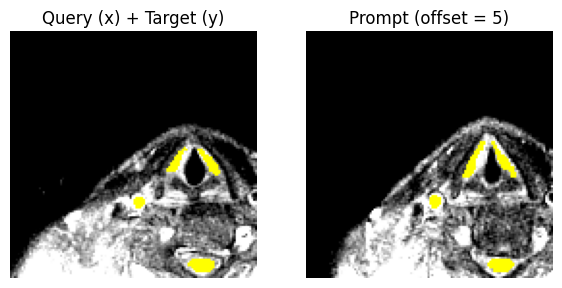

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6308044..2.1275258].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.657043..3.0425963].



x: -0.6668824553489685 - 2.888444662094116 | y: 0.0 - 1.0 | p (img): -0.7193596363067627 - 3.47225284576416 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


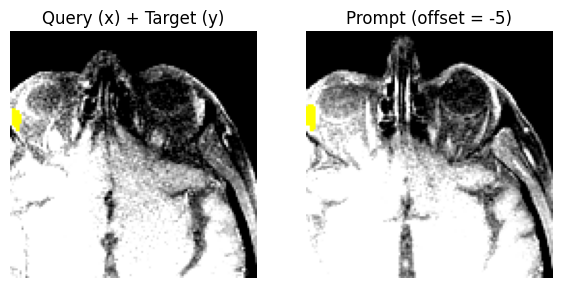

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81447446..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8013552..3.5608082].



x: -0.6308044195175171 - 2.708054304122925 | y: 0.0 - 1.0 | p (img): -0.6570429801940918 - 3.1770689487457275 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


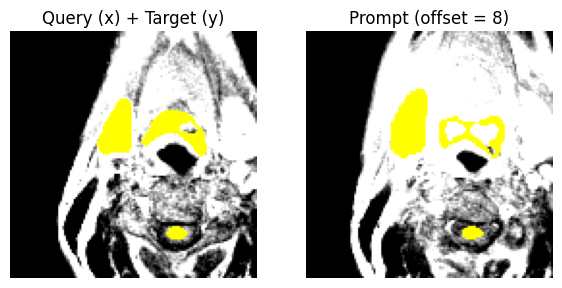

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.3476198].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.5608082].



x: -0.8144744634628296 - 3.5608081817626953 | y: 0.0 - 1.0 | p (img): -0.8013551831245422 - 3.5608081817626953 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


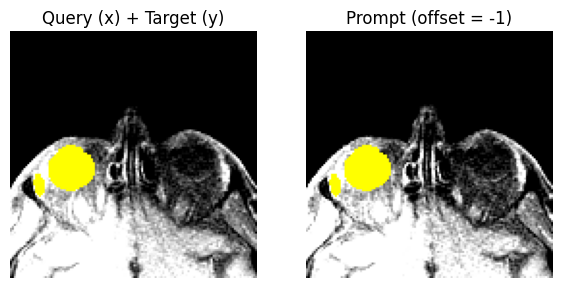

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8210341..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.804635..3.5608082].



x: -5.0 - 3.3476197719573975 | y: 0.0 - 1.0 | p (img): -5.0 - 3.5608081817626953 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


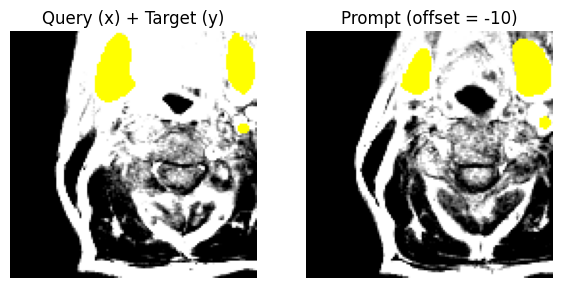

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76855695..3.5148907].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77183676..2.8195684].



x: -0.8210340738296509 - 3.5608081817626953 | y: 0.0 - 1.0 | p (img): -0.8046349883079529 - 3.5608081817626953 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


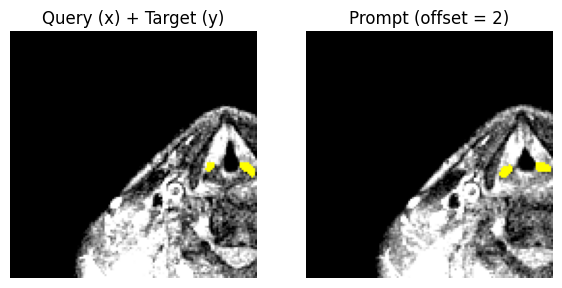


x: -0.7685569524765015 - 3.514890670776367 | y: 0.0 - 1.0 | p (img): -0.7718367576599121 - 2.819568395614624 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


In [10]:
for counter,(x,y,p) in enumerate(ds):
    plot_one_dp(x,y,p, offset_list[counter])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if counter == 5:
        break